# ハイブリッド量子ニューラルネットワーク (HQNN)

このチュートリアルでは、古典ニューラルネットワーク層と量子変分回路層を組み合わせた**ハイブリッド量子ニューラルネットワーク** (HQNN) を Fashion-MNIST データセットで構築します。量子層は Qamomile の `@qkernel` API で定義し、Qiskit にトランスパイルした上で、パラメータシフトルールを用いて PyTorch の学習パイプラインに統合します。

## アーキテクチャ

CNN 特徴抽出器・量子層・fusion 分類器の全体を、**最初から end-to-end で学習**します：

```
入力画像 → CNN → π·σ(·) → 量子層 → [CNN特徴, 量子出力] → 分類器 → 出力
```

分類器に古典 CNN 特徴と量子期待値の両方を入力する fusion 構造により、CNN と量子層が最初から協調して学習できます。

## インポートとセットアップ

In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

import qamomile.circuit as qmc
import qamomile.observable as qmo
from qamomile.qiskit import QiskitTranspiler
from qamomile.qiskit.observable import hamiltonian_to_sparse_pauli_op
from qiskit.primitives import StatevectorEstimator

In [2]:
N_QUBITS = 4
N_LAYERS = 2
N_WEIGHTS_PER_LAYER = N_QUBITS * 3  # 各量子ビットに RZ, RY, RZ
N_WEIGHTS = N_LAYERS * N_WEIGHTS_PER_LAYER

print(f"量子ビット数: {N_QUBITS}, 層数: {N_LAYERS}, 学習パラメータ数: {N_WEIGHTS}")

量子ビット数: 4, 層数: 2, 学習パラメータ数: 24


## @qkernel で変分アンザッツを定義

Qamomile の `@qkernel` デコレータを使ってパラメータ付き量子回路を定義します。回路は以下の構成です：

1. **角度エンコーディング**: 各入力特徴量を対応する量子ビットの RY 回転として埋め込みます。
2. **変分層**: 各層で学習可能な重みによる RZ–RY–RZ 回転を適用し、その後 CNOT のエンタングルメントラダーを実行します。

回路は測定結果を古典ビットとして返します。

In [3]:
@qmc.qkernel
def variational_ansatz(
    n_qubits: qmc.UInt,
    n_layers: qmc.UInt,
    inputs: qmc.Vector[qmc.Float],
    weights: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n_qubits, name="q")

    # 角度エンコーディング: 古典特徴量を RY 回転で埋め込み
    for i in qmc.range(n_qubits):
        q[i] = qmc.ry(q[i], inputs[i])

    # 変分層
    for l in qmc.range(n_layers):
        base = l * n_qubits * 3
        # RZ-RY-RZ 単一量子ビット回転
        for i in qmc.range(n_qubits):
            q[i] = qmc.rz(q[i], weights[base + i])
        for i in qmc.range(n_qubits):
            q[i] = qmc.ry(q[i], weights[base + n_qubits + i])
        for i in qmc.range(n_qubits):
            q[i] = qmc.rz(q[i], weights[base + n_qubits * 2 + i])

        # CNOT エンタングルメントラダー
        for i in qmc.range(n_qubits - 1):
            q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])

    return qmc.measure(q)

回路構造を可視化してみましょう：

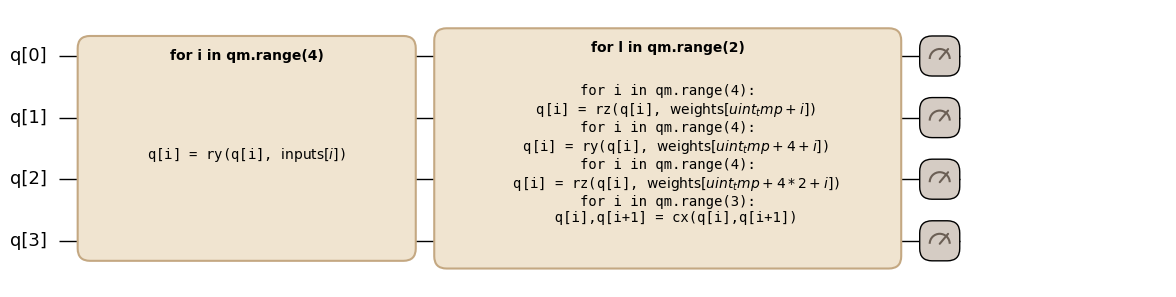

In [4]:
variational_ansatz.draw(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    inputs=[0.1] * N_QUBITS,
    weights=[0.1] * N_WEIGHTS,
)

## Qiskit へトランスパイル

`@qkernel` を Qiskit の `QuantumCircuit` にトランスパイルします。`inputs` と `weights` はシンボリックパラメータとして保持し、実行時にバインドできるようにします。

In [5]:
transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    variational_ansatz,
    bindings={"n_qubits": N_QUBITS, "n_layers": N_LAYERS},
    parameters=["inputs", "weights"],
)

# シンボリックパラメータ付きの Qiskit 回路を取得
qiskit_circuit = executable.get_first_circuit()
param_metadata = executable.compiled_quantum[0].parameter_metadata

print(f"回路の深さ: {qiskit_circuit.depth()}")
print(f"パラメータ数: {qiskit_circuit.num_parameters}")

回路の深さ: 13
パラメータ数: 28


## オブザーバブルの定義

各量子ビットの期待値 $\langle Z_i \rangle$ を測定します。これらの期待値が量子層の出力となります。

In [6]:
# 各量子ビットのハミルトニアン: <Z_i>
# 回路サイズに合わせて num_qubits を指定
observables = []
for i in range(N_QUBITS):
    h = qmo.Hamiltonian(num_qubits=N_QUBITS)
    h.add_term((qmo.PauliOperator(qmo.Pauli.Z, i),), 1.0)
    observables.append(h)

# Qiskit の SparsePauliOp に変換
qiskit_obs = [hamiltonian_to_sparse_pauli_op(obs) for obs in observables]

# 期待値推定のため、回路から終端の測定を除去
ansatz_no_meas = qiskit_circuit.remove_final_measurements(inplace=False)

estimator = StatevectorEstimator()

## 量子フォワードパス

フォワードパスでは、回路パラメータに具体的な値をバインドし、`StatevectorEstimator` を使って各量子ビットの $\langle Z_i \rangle$ を評価します。

In [7]:
def expand_bindings(bindings: dict) -> dict:
    """ベクトルバインディングをインデックス付き形式に展開する。"""
    result = {}
    for key, value in bindings.items():
        if isinstance(value, (list, tuple, np.ndarray)):
            for i, v in enumerate(value):
                result[f"{key}[{i}]"] = v
        else:
            result[key] = value
    return result


def quantum_forward(input_vals: np.ndarray, weight_vals: np.ndarray) -> np.ndarray:
    """各量子ビットの <Z_i> を評価する。

    Args:
        input_vals: 特徴量の値、shape (N_QUBITS,)。
        weight_vals: 学習可能な重み、shape (N_WEIGHTS,)。

    Returns:
        期待値、shape (N_QUBITS,)。
    """
    indexed = expand_bindings({"inputs": list(input_vals), "weights": list(weight_vals)})
    binding_dict = param_metadata.to_binding_dict(indexed)
    bound_circuit = ansatz_no_meas.assign_parameters(binding_dict)

    # 全オブザーバブルの評価を一括で実行
    pubs = [(bound_circuit, obs) for obs in qiskit_obs]
    job = estimator.run(pubs)
    results = job.result()

    return np.array([float(r.data.evs) for r in results])

In [8]:
# 動作テスト: ランダムな入力と重み
rng = np.random.default_rng(42)
test_inputs = rng.uniform(-np.pi, np.pi, N_QUBITS)
test_weights = rng.uniform(-np.pi, np.pi, N_WEIGHTS)

expvals = quantum_forward(test_inputs, test_weights)
print("期待値:", expvals)

期待値: [ 0.00909923  0.25403499  0.31838452 -0.06170293]


## パラメータシフトルールによる勾配計算

PyTorch の autograd で量子層を学習するには、すべてのパラメータに関する期待値の勾配が必要です。$e^{-i\theta G/2}$ 形式のゲートに対して、**パラメータシフトルール**は厳密な勾配公式を与えます：

$$
\frac{\partial}{\partial \theta_k} \langle Z_i \rangle
= \frac{1}{2} \Big[
    \langle Z_i \rangle\big|_{\theta_k + \pi/2}
  - \langle Z_i \rangle\big|_{\theta_k - \pi/2}
\Big]
$$

これをカスタム `torch.autograd.Function` として実装し、PyTorch が量子層を通じて誤差逆伝播できるようにします。

In [9]:
SHIFT = math.pi / 2


class QuantumFunction(torch.autograd.Function):
    """PyTorch と量子回路を橋渡しするカスタム autograd 関数。"""

    @staticmethod
    def forward(ctx, inputs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(inputs, weights)
        # バッチ内の各サンプルに対して回路を評価
        batch_results = []
        for inp in inputs:
            expvals = quantum_forward(inp.detach().numpy(), weights.detach().numpy())
            batch_results.append(expvals)
        return torch.tensor(np.array(batch_results), dtype=torch.float32)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        inputs, weights = ctx.saved_tensors
        weights_np = weights.detach().numpy()

        grad_inputs = torch.zeros_like(inputs)
        grad_weights = torch.zeros(weights.shape[0], dtype=torch.float32)

        for b, inp in enumerate(inputs):
            inp_np = inp.detach().numpy()
            g_out = grad_output[b].numpy()  # shape (N_QUBITS,)

            # 重みに関する勾配
            for k in range(len(weights_np)):
                shifted_plus = weights_np.copy()
                shifted_plus[k] += SHIFT
                shifted_minus = weights_np.copy()
                shifted_minus[k] -= SHIFT

                fwd_plus = quantum_forward(inp_np, shifted_plus)
                fwd_minus = quantum_forward(inp_np, shifted_minus)
                param_grad = (fwd_plus - fwd_minus) / 2.0  # shape (N_QUBITS,)

                grad_weights[k] += np.dot(g_out, param_grad)

            # 入力に関する勾配
            for k in range(len(inp_np)):
                shifted_plus = inp_np.copy()
                shifted_plus[k] += SHIFT
                shifted_minus = inp_np.copy()
                shifted_minus[k] -= SHIFT

                fwd_plus = quantum_forward(shifted_plus, weights_np)
                fwd_minus = quantum_forward(shifted_minus, weights_np)
                input_grad = (fwd_plus - fwd_minus) / 2.0

                grad_inputs[b, k] = np.dot(g_out, input_grad)

        return grad_inputs, grad_weights

## 量子層を PyTorch モジュールとして定義

autograd 関数を標準的な `nn.Module` でラップし、他の層と組み合わせられるようにします。

In [10]:
class QLayer(nn.Module):
    """Qamomile 変分回路をラップする PyTorch モジュール。"""

    def __init__(self, n_weights: int):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_weights) * 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return QuantumFunction.apply(x, self.weights)

## データの準備 (Fashion-MNIST)

[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) データセットから4つの視覚的に異なるクラスのサブセットを使用します。Fashion-MNIST は 28×28 のグレースケール衣類画像で構成されるデータセットです。

計算時間を抑えるため、4クラス（T-shirt、Trouser、Sandal、Bag）を選択し、各クラス60枚の訓練データ、30枚のテストデータを使用します。

In [11]:
import os

N_CLASSES = 4
SELECTED_CLASSES = [0, 1, 5, 8]  # T-shirt, Trouser, Sandal, Bag
CLASS_NAMES = ["T-shirt", "Trouser", "Sandal", "Bag"]
N_TRAIN_PER_CLASS = 60
N_TEST_PER_CLASS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

# 永続キャッシュディレクトリを使用（再ダウンロードを回避）
_data_root = os.path.join(os.path.expanduser("~"), ".cache", "fashion_mnist")
full_train = datasets.FashionMNIST(
    root=_data_root, train=True, download=True, transform=transform
)
full_test = datasets.FashionMNIST(
    root=_data_root, train=False, download=True, transform=transform
)


def subset_dataset(dataset, classes, n_per_class):
    """指定クラスからランダムにサブセットを抽出する。"""
    images, labels = [], []
    rng_data = np.random.default_rng(0)
    for new_label, orig_label in enumerate(classes):
        indices = [i for i, (_, y) in enumerate(dataset) if y == orig_label]
        chosen = rng_data.choice(indices, size=n_per_class, replace=False)
        for idx in chosen:
            img, _ = dataset[idx]
            images.append(img)
            labels.append(new_label)
    return torch.stack(images), torch.tensor(labels)


X_train, y_train = subset_dataset(full_train, SELECTED_CLASSES, N_TRAIN_PER_CLASS)
X_test, y_test = subset_dataset(full_test, SELECTED_CLASSES, N_TEST_PER_CLASS)

print(f"訓練データ: {X_train.shape}, テストデータ: {X_test.shape}")
print(f"クラス: {CLASS_NAMES}")

訓練データ: torch.Size([240, 1, 28, 28]), テストデータ: torch.Size([120, 1, 28, 28])
クラス: ['T-shirt', 'Trouser', 'Sandal', 'Bag']


## End-to-End ハイブリッドモデル

ハイブリッドモデル全体を**最初から end-to-end で学習**します。CNN 特徴抽出器と量子層が協調学習します。損失関数から分類器、量子層（パラメータシフトルール経由）、CNN へと勾配が流れます。

```
入力画像 → [CNN 特徴抽出器] → π·σ(·) → [量子層] → [CNN特徴, 量子出力] → [分類器] → 出力
```

- **Sigmoid スケーリング**: $\pi \cdot \sigma(\cdot)$ で CNN 出力を $(0, \pi)$ に写し、角度の wrap-around を抑える。
- **Fusion 分類器**: `[CNN特徴, 量子出力]` を結合し、古典と量子の両方の表現を分類器に入力。

In [12]:
class EndToEndHybridHQNN(nn.Module):
    """
    end-to-end 用のハイブリッドモデル（最初から全体を学習）。
    画像 -> CNN特徴 -> 量子層 -> 分類器

    分類器には [古典特徴, 量子出力] を両方入れる fusion 構造。
    CNN と量子層が最初から協調して学習する。
    """

    def __init__(self, n_qubits: int, n_weights: int, n_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(4, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, n_qubits),
        )
        self.qlayer = QLayer(n_weights)
        self.classifier = nn.Linear(n_qubits * 2, n_classes)

    def forward(self, x: torch.Tensor):
        # CNN特徴を量子層入力の角度へ
        feats = math.pi * torch.sigmoid(self.feature_extractor(x))   # shape: (B, N_QUBITS)
        q_out = self.qlayer(feats)                                   # shape: (B, N_QUBITS)

        fused = torch.cat([feats, q_out], dim=1)                     # shape: (B, 2*N_QUBITS)
        logits = self.classifier(fused)
        return logits, feats, q_out


EPOCHS = 10
BATCH_SIZE = 4

torch.manual_seed(42)
hybrid_model = EndToEndHybridHQNN(N_QUBITS, N_WEIGHTS, N_CLASSES)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []

print(f"=== End-to-End 学習 ({EPOCHS} エポック) ===")
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    total = 0

    for i in range(0, len(X_shuf), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]
        yb = y_shuf[i : i + BATCH_SIZE]

        optimizer.zero_grad()
        logits, feats, q_out = hybrid_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total += len(yb)

    avg_loss = epoch_loss / max(1, math.ceil(total / BATCH_SIZE))
    train_losses.append(avg_loss)

    with torch.no_grad():
        test_logits, _, _ = hybrid_model(X_test)
        test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
        test_accs.append(test_acc)

    print(f"  エポック {epoch + 1}/{EPOCHS}  損失={avg_loss:.4f}  テスト精度={test_acc:.2%}")

=== End-to-End 学習 (10 エポック) ===


  エポック 1/10  損失=1.2718  テスト精度=79.17%


  エポック 2/10  損失=0.7916  テスト精度=96.67%


  エポック 3/10  損失=0.5905  テスト精度=95.00%


  エポック 4/10  損失=0.4901  テスト精度=93.33%


...

  エポック 6/10  損失=0.3795  テスト精度=93.33%


  エポック 7/10  損失=0.3432  テスト精度=94.17%


  エポック 8/10  損失=0.2928  テスト精度=94.17%


  エポック 9/10  損失=0.2730  テスト精度=96.67%


  エポック 10/10  損失=0.2620  テスト精度=96.67%


In [13]:
# 勾配が CNN と量子層の両方に流れているか確認
xb = X_train[:BATCH_SIZE]
yb = y_train[:BATCH_SIZE]

optimizer.zero_grad()
logits, feats, q_out = hybrid_model(xb)
loss = criterion(logits, yb)
loss.backward()

print("feature_extractor first conv grad mean:",
      hybrid_model.feature_extractor[0].weight.grad.abs().mean().item())
print("quantum weights grad mean:",
      hybrid_model.qlayer.weights.grad.abs().mean().item())

optimizer.zero_grad()

feature_extractor first conv grad mean: 0.08279561996459961
quantum weights grad mean: 0.009317319840192795


## 評価

In [14]:
with torch.no_grad():
    q_logits, F_test_e2e, q_outputs = hybrid_model(X_test)
    preds = q_logits.argmax(1)
    quantum_acc = (preds == y_test).float().mean().item()

print(f"end-to-end 量子モデルの精度: {quantum_acc:.2%}")
print()

for c in range(N_CLASSES):
    mask = y_test == c
    class_acc = (preds[mask] == y_test[mask]).float().mean().item()
    print(f"  {CLASS_NAMES[c]}: {class_acc:.2%}")

end-to-end 量子モデルの精度: 96.67%

  T-shirt: 90.00%
  Trouser: 100.00%
  Sandal: 100.00%
  Bag: 96.67%


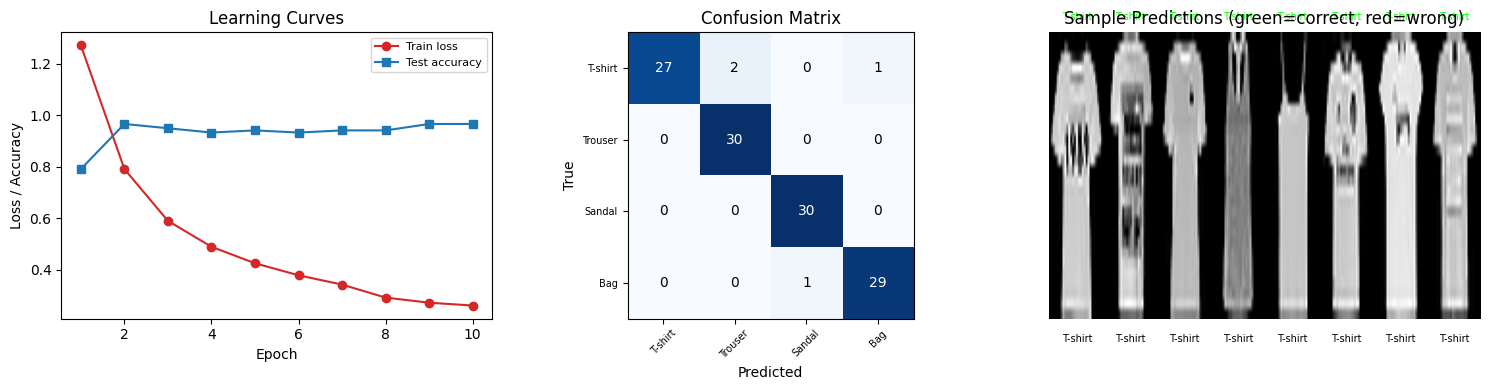

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Learning curves
ax = axes[0]
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, "o-", color="C3", label="Train loss")
ax.plot(epochs_range, test_accs, "s-", color="C0", label="Test accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / Accuracy")
ax.set_title("Learning Curves")
ax.legend(fontsize=8)

# (b) Confusion matrix
conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_test.numpy(), preds.numpy()):
    conf[t, p] += 1
axes[1].imshow(conf, cmap="Blues")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, fontsize=7, rotation=45)
axes[1].set_yticklabels(CLASS_NAMES, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(
            j, i, str(conf[i, j]), ha="center", va="center",
            color="white" if conf[i, j] > conf.max() / 2 else "black",
        )

# (c) Sample images with predictions
n_show = min(8, len(X_test))
sample_imgs = X_test[:n_show, 0].numpy()
combined = np.concatenate(sample_imgs, axis=1)
axes[2].imshow(combined, cmap="gray", aspect="auto")
for i in range(n_show):
    color = "lime" if preds[i] == y_test[i] else "red"
    axes[2].text(
        28 * i + 14, -1.5,
        CLASS_NAMES[preds[i].item()],
        ha="center", va="bottom", fontsize=7, color=color,
    )
    axes[2].text(
        28 * i + 14, 29,
        CLASS_NAMES[y_test[i].item()],
        ha="center", va="top", fontsize=7,
    )
axes[2].set_title("Sample Predictions (green=correct, red=wrong)")
axes[2].axis("off")

plt.tight_layout()
plt.show()